In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


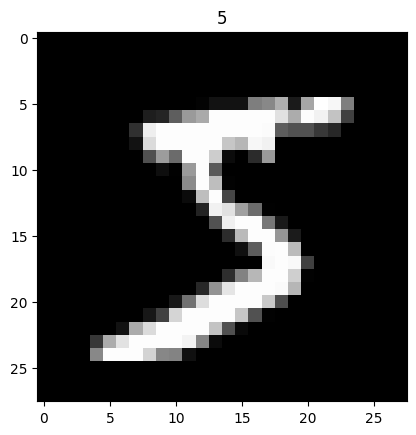

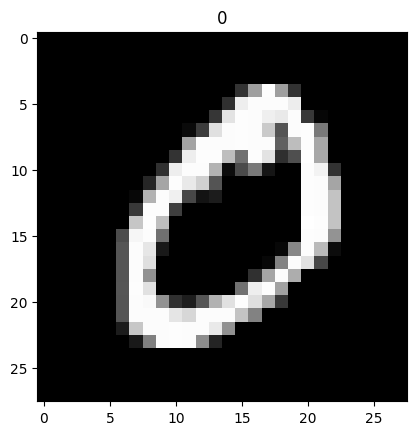

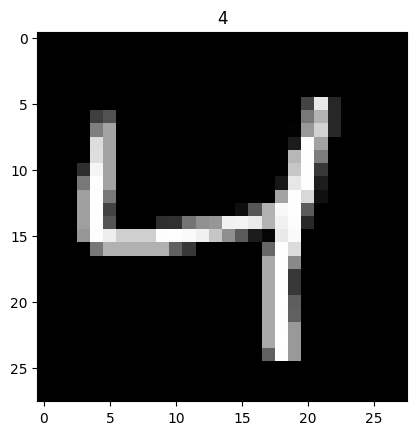

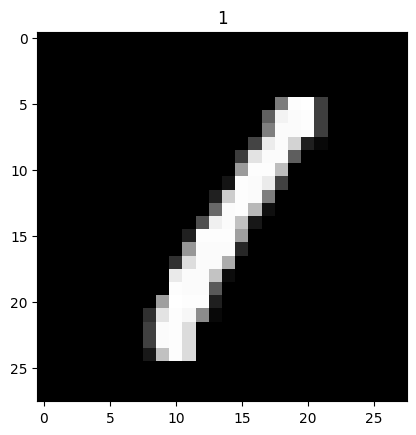

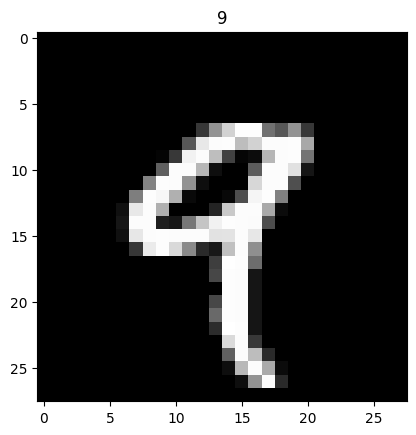

In [5]:
for i in range(5):
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.show()

{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


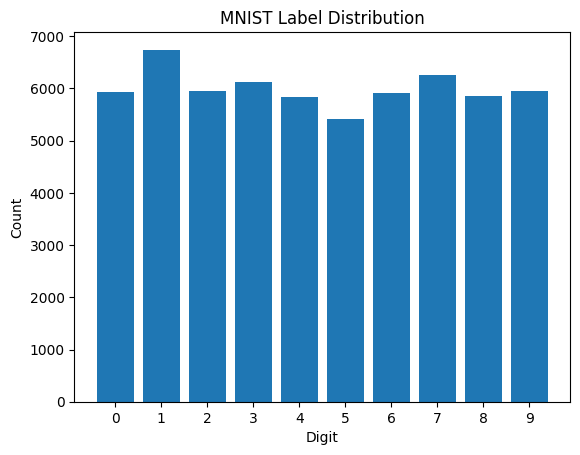

In [8]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))
plt.bar(unique, counts)
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("MNIST Label Distribution")
plt.xticks(unique)
plt.show()

## Problem Definition

Let the dataset be a subset of the MNIST dataset restricted to two classes: digits **0** and **1**. We define the training dataset as:

$$
\mathcal{D} = {(x^{(i)}, y^{(i)})}_{i=1}^{N}
$$

where:

* $x^{(i)} \in \mathbb{R}^{28 \times 28}$ represents the $i$-th grayscale image
* After flattening: $x^{(i)} \in \mathbb{R}^{784}$
* $y^{(i)} \in {0,1}$ is the corresponding label

---

The objective is to learn a function:

$$
f_\theta : \mathbb{R}^{784} \rightarrow {0,1}
$$

parameterized by $\theta$, that maps an input image to its correct class.

---

In probabilistic form, we model:

$$
P(y = 1 \mid x; \theta)
$$

and define the prediction as:

$$
\hat{y} =
\begin{cases}
1 & \text{if } P(y = 1 \mid x; \theta) \geq 0.5 \
0 & \text{otherwise}
\end{cases}
$$

---

The learning objective is to find optimal parameters $\theta^*$ that minimize a loss function over the dataset:

$$
\theta^* = \arg\min_{\theta} \frac{1}{N} \sum_{i=1}^{N} \mathcal{L}(f_\theta(x^{(i)}), y^{(i)})
$$

---

For example, using binary cross-entropy loss:

$$
\mathcal{L}(y, \hat{y}) = - \left[ y \log(\hat{y}) + (1 - y)\log(1 - \hat{y}) \right]
$$

---

Thus, the problem is formulated as a **supervised binary classification task** in a high-dimensional feature space $\mathbb{R}^{784}$, where the goal is to learn a decision boundary that separates the two classes (digits 0 and 1).


#Data Processing

In [10]:
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)



In [11]:
mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]
print("X shape:", X.shape)
print("y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)
print("Class distribution:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count}")

X shape: (14780, 28, 28)
y shape: (14780,)
Class distribution:
Class 0: 6903
Class 1: 7877


In [12]:
X = X.astype(np.float32) / 255.0
X = X.reshape(X.shape[0], -1)
print("Shape after flattening:", X.shape)

Shape after flattening: (14780, 784)


In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (10346, 784) (10346,)
Validation shape: (2217, 784) (2217,)
Test shape: (2217, 784) (2217,)


In [14]:
# =========================
# Feature Normalization (Standardization)
# =========================

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# avoid division by zero
std[std == 0] = 1

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std